In [1]:
# 1. Instalación de librerías de Inteligencia Artificial y Gráficos
!pip install scikit-learn seaborn matplotlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Fase 1: Generando Dataset Bancario Confidencial ---")

# Fijamos la semilla para que los datos aleatorios sean reproducibles
np.random.seed(42)

# Simulamos 5000 solicitudes de préstamos
n_clientes = 5000

# Variables demográficas y financieras lógicas
edad = np.random.randint(18, 70, n_clientes)
ingresos = np.random.normal(50000, 20000, n_clientes).clip(15000, 200000) # Campana de Gauss para sueldos
deuda_actual = np.random.normal(15000, 10000, n_clientes).clip(0, 100000)
antiguedad_empleo = np.random.randint(0, 20, n_clientes)

# El Ratio DTI (Debt-to-Income) es el predictor más fuerte de impago en la realidad
dti_ratio = deuda_actual / ingresos

# Lógica Oculta de Impago (La "Verdad" que la IA tendrá que descubrir)
# Si tu DTI es altísimo, eres muy joven o tienes poco sueldo, la probabilidad de impago (Default) sube drásticamente.
probabilidad_impago = (dti_ratio * 0.4) + (np.where(edad < 25, 0.2, 0)) + (np.where(ingresos < 25000, 0.2, 0))
probabilidad_impago = probabilidad_impago + np.random.normal(0, 0.1, n_clientes) # Añadimos ruido estadístico realista

# 1 = Default (No paga), 0 = Pagado
target_default = np.where(probabilidad_impago > 0.4, 1, 0)

# Construir el DataFrame final
df_banco = pd.DataFrame({
    'Edad': edad,
    'Ingresos_Anuales': ingresos,
    'Deuda_Actual': deuda_actual,
    'Ratio_DTI': dti_ratio,
    'Anos_Empleo': antiguedad_empleo,
    'Default': target_default
})

# Redondear numéricos
df_banco = df_banco.round({'Ingresos_Anuales': 2, 'Deuda_Actual': 2, 'Ratio_DTI': 4})

print(f"✅ Base de datos generada: {df_banco.shape[0]} registros y {df_banco.shape[1]} variables.")
print(f"🚨 Tasa de impagos histórica (Defaults): {df_banco['Default'].mean() * 100:.2f}% de la cartera.")

display(df_banco.head())

--- Fase 1: Generando Dataset Bancario Confidencial ---
✅ Base de datos generada: 5000 registros y 6 variables.
🚨 Tasa de impagos histórica (Defaults): 12.92% de la cartera.


,Edad,Ingresos_Anuales,Deuda_Actual,Ratio_DTI,Anos_Empleo,Default
0,56,47804.61,29073.00,0.6082,3,0
1,69,59949.71,19078.10,0.3182,1,0
2,46,42292.33,23162.22,0.5477,18,0
3,32,58409.05,4414.32,0.0756,4,0
4,60,32712.18,24839.24,0.7593,8,0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Fase 2: Preprocesamiento de Datos ---")

# 1. Separar las 'X' (Características) de la 'y' (El Objetivo a predecir)
X = df_banco.drop('Default', axis=1) # Todo menos la columna Default
y = df_banco['Default']              # Solo la columna Default

# 2. Dividir en Entrenamiento (80%) y Testeo (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Datos divididos: {X_train.shape[0]} clientes para entrenar, {X_test.shape[0]} para examinar a la IA.")

# 3. Estandarización Matemática (Crucial para que la IA no se confunda con números muy grandes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Ojo: Solo 'transform' para no dar pistas del Test

print("--- Fase 3: Entrenamiento del Modelo de Regresión Logística ---")

# 4. Instanciar el "Cerebro" Matemático (Regresión Logística)
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)

# 5. EL ENTRENAMIENTO: Aquí es donde ocurre la magia del Machine Learning
modelo_lr.fit(X_train_scaled, y_train)
print("✅ ¡Modelo entrenado con éxito! La IA ha aprendido los patrones de impago.")

# 6. Ponerle el examen final (Evaluar con los datos que nunca ha visto)
y_pred = modelo_lr.predict(X_test_scaled)

# 7. Imprimir la nota del examen (Accuracy)
precision_general = accuracy_score(y_test, y_pred)
print(f"🎯 Precisión Global (Accuracy): {precision_general * 100:.2f}% de acierto en el examen final.")

--- Fase 2: Preprocesamiento de Datos ---
Datos divididos: 4000 clientes para entrenar, 1000 para examinar a la IA.
--- Fase 3: Entrenamiento del Modelo de Regresión Logística ---
✅ ¡Modelo entrenado con éxito! La IA ha aprendido los patrones de impago.
🎯 Precisión Global (Accuracy): 85.50% de acierto en el examen final.


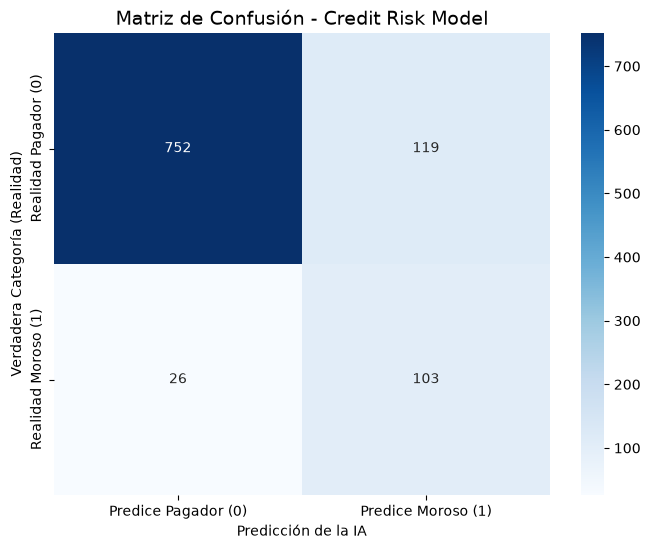


--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       871
           1       0.46      0.80      0.59       129

    accuracy                           0.85      1000
   macro avg       0.72      0.83      0.75      1000
weighted avg       0.90      0.85      0.87      1000



In [3]:
# 1. Crear la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# 2. Dibujarla con un mapa de calor (Seaborn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predice Pagador (0)', 'Predice Moroso (1)'], 
            yticklabels=['Realidad Pagador (0)', 'Realidad Moroso (1)'])

plt.title('Matriz de Confusión - Credit Risk Model', fontsize=14)
plt.ylabel('Verdadera Categoría (Realidad)')
plt.xlabel('Predicción de la IA')
plt.show()

# 3. Mostrar el reporte detallado (Recall es la métrica clave aquí)
print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(y_test, y_pred))

In [4]:
print("--- Simulador Predictivo de Riesgo Crediticio ---")

def simular_credito(edad, ingresos, deuda, anos_empleo):
    # 1. Calculamos el DTI en tiempo real, igual que hicimos en el entrenamiento
    dti = deuda / ingresos
    
    # 2. Creamos el perfil del solicitante como un DataFrame 
    # (¡Ojo! Las columnas deben estar en el mismo orden exacto que cuando entrenamos la IA)
    nuevo_cliente = pd.DataFrame({
        'Edad': [edad],
        'Ingresos_Anuales': [ingresos],
        'Deuda_Actual': [deuda],
        'Ratio_DTI': [dti],
        'Anos_Empleo': [anos_empleo]
    })
    
    # 3. Escalar matemáticamente los datos del nuevo cliente usando nuestro 'scaler' entrenado
    cliente_escalado = scaler.transform(nuevo_cliente)
    
    # 4. Pedirle a la IA la decisión y el % de seguridad
    prediccion = modelo_lr.predict(cliente_escalado)[0]
    probabilidad = modelo_lr.predict_proba(cliente_escalado)[0]
    
    print("\n-----------------------------------------")
    print(f"📊 PERFIL DEL SOLICITANTE:")
    print(f"   Edad: {edad} | Ingresos: {ingresos}€ | Deuda: {deuda}€ (DTI: {dti:.2f})")
    print("-----------------------------------------")
    
    if prediccion == 1:
        print("❌ DENEGADO: El modelo predice IMPAGO (Default).")
        print(f"   Riesgo estimado: {probabilidad[1]*100:.2f}%")
    else:
        print("✅ APROBADO: El modelo predice PAGO CORRECTO.")
        print(f"   Seguridad en el pago: {probabilidad[0]*100:.2f}%")
        
# --- ZONA DE PRUEBAS ---
# Prueba 1: Un perfil joven, con sueldo medio pero ahogado en deudas
simular_credito(edad=24, ingresos=30000, deuda=25000, anos_empleo=1)

# Prueba 2: Un perfil maduro, buen sueldo y deudas controladas
simular_credito(edad=45, ingresos=90000, deuda=15000, anos_empleo=15)

--- Simulador Predictivo de Riesgo Crediticio ---

-----------------------------------------
📊 PERFIL DEL SOLICITANTE:
   Edad: 24 | Ingresos: 30000€ | Deuda: 25000€ (DTI: 0.83)
-----------------------------------------
❌ DENEGADO: El modelo predice IMPAGO (Default).
   Riesgo estimado: 96.79%

-----------------------------------------
📊 PERFIL DEL SOLICITANTE:
   Edad: 45 | Ingresos: 90000€ | Deuda: 15000€ (DTI: 0.17)
-----------------------------------------
✅ APROBADO: El modelo predice PAGO CORRECTO.
   Seguridad en el pago: 98.03%
